<a href="https://colab.research.google.com/github/Hitesh04codebot/Ml-Lab/blob/main/LAB_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
# Column names as per UCI IRIS dataset
columns = [
"sepal_length",
"sepal_width",
"petal_length",
"petal_width",
"species"
]
# Load the IRIS Dataset (NO HEADER in iris.data)
data = pd.read_csv("iris.data", header=None, names=columns)
# Separate features and target
df = data.drop("species", axis=1)
print("First five rows of dataset:")
print(df.head())
# Feature Scaling
scaler = StandardScaler()

First five rows of dataset:
     sepal_length   sepal_width   petal_length   petal_width
Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
1             5.1           3.5            1.4           0.2
2             4.9           3.0            1.4           0.2
3             4.7           3.2            1.3           0.2
4             4.6           3.1            1.5           0.2



K-Means Silhouette Score: 0.5106191111995846
Hierarchical Clustering Silhouette Score: 0.5831000490985977


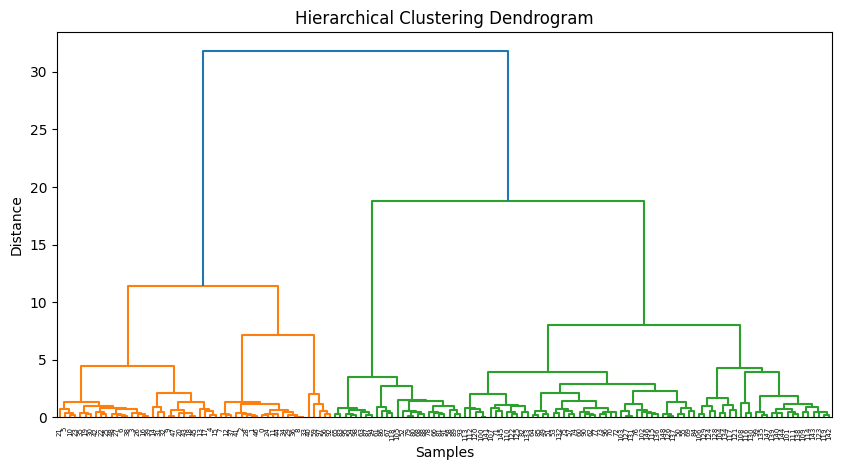

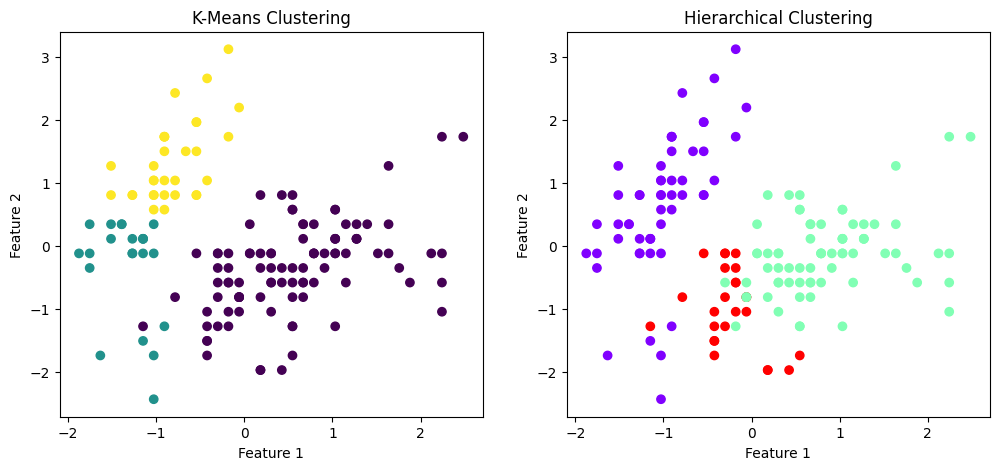

In [ ]:
# Drop the problematic row (which contains string headers mistaken as data)
df = df.drop(df.index[0], axis=0)
X_scaled = scaler.fit_transform(df)
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("\nK-Means Silhouette Score:", kmeans_silhouette)
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df['Hierarchical_Cluster'] = hierarchical_labels
# Evaluate Hierarchical clustering
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()
# Visualization of Clusters
plt.figure(figsize=(12,5))
# KMeans Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()